## Problem Statement

The project focuses on leveraging machine learning techniques to address two distinct challenges:

* Part A: Predicting the signal quality of a communications equipment manufacturing company's product using various measurable signal parameters. The goal is to build a robust classifier that can assess signal strength or quality accurately.

* Part B: Developing a digit recognition model for the Street View Housing Number (SVHN) dataset. This involves building a neural network-based digit classifier to transcribe prominent numbers from street-level images, aiding applications like map-making and address identification.

These tasks involve data preprocessing, exploratory analysis, and building, training, and optimizing neural network models.

In [1]:
!pip install tensorflow

In [2]:

#%tensorflow_version 2.x
import tensorflow as tf
tf.__version__

'2.17.1'

## Part A - Q1 A - Read the ‘Signals.csv’ as DatFrame and import required libraries.

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import scipy.stats as stats
import matplotlib.pyplot as plt
from tensorflow import keras
#from keras.models import Sequential
#from keras.layers import Dense
#from sklearn.model_selection import StratifiedKFold
%matplotlib inline
#Test Train Split
from sklearn.model_selection import train_test_split
#Feature Scaling library
from sklearn.preprocessing import StandardScaler
#import pickle
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras import regularizers, optimizers
from sklearn.metrics import r2_score
from tensorflow.keras.models import load_model

In [4]:
# Ignore the warnings
import warnings
warnings.filterwarnings("ignore")

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [55]:
## Complete the code to import the data
df = pd.read_csv('/content/drive/MyDrive/Signal.csv')

## Q1 B: Check for missing values and print percentage for each attribute.

In [56]:
# Q1 B: Check for missing values and print percentage for each attribute.
missing_values = df.isnull().mean() * 100
print("Missing values percentage:\n", missing_values)

Missing values percentage:
 Parameter 1        0.0
Parameter 2        0.0
Parameter 3        0.0
Parameter 4        0.0
Parameter 5        0.0
Parameter 6        0.0
Parameter 7        0.0
Parameter 8        0.0
Parameter 9        0.0
Parameter 10       0.0
Parameter 11       0.0
Signal_Strength    0.0
dtype: float64


# Q1 C: Check for presence of duplicate records in the dataset and impute with appropriate method.


In [57]:
# Show duplicate rows in the dataframe
df[df.duplicated()]


,Parameter 1,Parameter 2,Parameter 3,Parameter 4,Parameter 5,Parameter 6,Parameter 7,Parameter 8,Parameter 9,Parameter 10,Parameter 11,Signal_Strength
4,7.4,0.700,0.00,1.90,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
11,7.5,0.500,0.36,6.10,0.071,17.0,102.0,0.99780,3.35,0.80,10.5,5
27,7.9,0.430,0.21,1.60,0.106,10.0,37.0,0.99660,3.17,0.91,9.5,5
40,7.3,0.450,0.36,5.90,0.074,12.0,87.0,0.99780,3.33,0.83,10.5,5
65,7.2,0.725,0.05,4.65,0.086,4.0,11.0,0.99620,3.41,0.39,10.9,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1563,7.2,0.695,0.13,2.00,0.076,12.0,20.0,0.99546,3.29,0.54,10.1,5
1564,7.2,0.695,0.13,2.00,0.076,12.0,20.0,0.99546,3.29,0.54,10.1,5
1567,7.2,0.695,0.13,2.00,0.076,12.0,20.0,0.99546,3.29,0.54,10.1,5
1581,6.2,0.560,0.09,1.70,0.053,24.0,32.0,0.99402,3.54,0.60,11.3,5


In [58]:
# dropping duplicate values
df.drop_duplicates(keep=False,inplace=True)
df[df.duplicated()]

,Parameter 1,Parameter 2,Parameter 3,Parameter 4,Parameter 5,Parameter 6,Parameter 7,Parameter 8,Parameter 9,Parameter 10,Parameter 11,Signal_Strength


In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1139 entries, 1 to 1598
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Parameter 1      1139 non-null   float64
 1   Parameter 2      1139 non-null   float64
 2   Parameter 3      1139 non-null   float64
 3   Parameter 4      1139 non-null   float64
 4   Parameter 5      1139 non-null   float64
 5   Parameter 6      1139 non-null   float64
 6   Parameter 7      1139 non-null   float64
 7   Parameter 8      1139 non-null   float64
 8   Parameter 9      1139 non-null   float64
 9   Parameter 10     1139 non-null   float64
 10  Parameter 11     1139 non-null   float64
 11  Signal_Strength  1139 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 115.7 KB


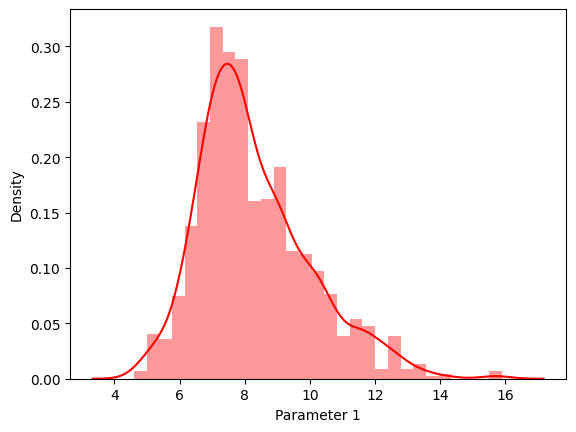

Distribution of  Parameter 1
Mean is: 8.287884108867427
Median is: 7.9
Mode is: 0    7.8
Name: Parameter 1, dtype: float64
Standard deviation is: 1.725695601250208
Skewness is: 0.889582473732798
Maximum is: 15.9
Minimum is: 4.6


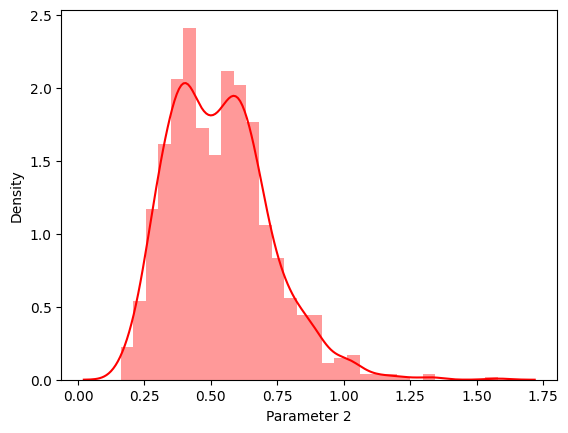

Distribution of  Parameter 2
Mean is: 0.5311720807726076
Median is: 0.52
Mode is: 0    0.58
Name: Parameter 2, dtype: float64
Standard deviation is: 0.18827869415178497
Skewness is: 0.7776814335236473
Maximum is: 1.58
Minimum is: 0.16


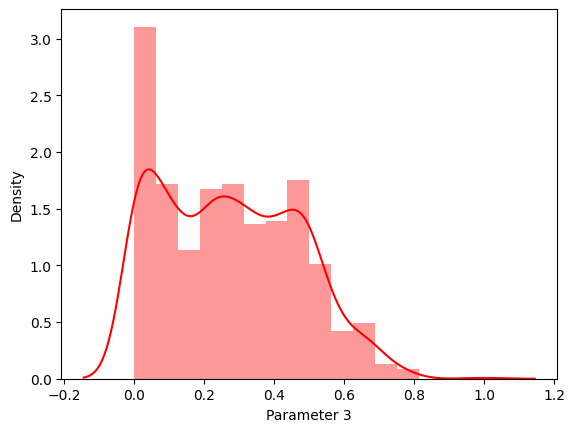

Distribution of  Parameter 3
Mean is: 0.273476733977173
Median is: 0.26
Mode is: 0    0.0
Name: Parameter 3, dtype: float64
Standard deviation is: 0.19637047617552122
Skewness is: 0.30409117401465385
Maximum is: 1.0
Minimum is: 0.0


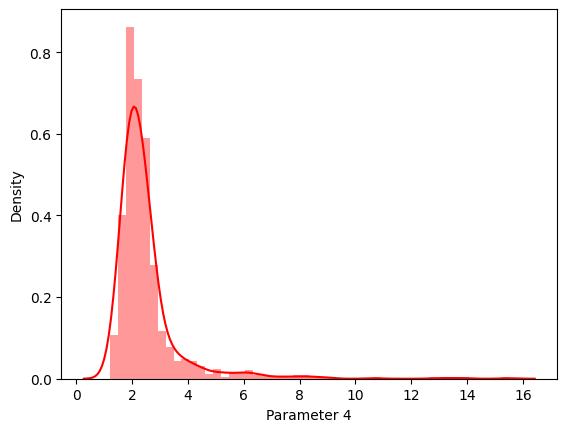

Distribution of  Parameter 4
Mean is: 2.493634767339772
Median is: 2.2
Mode is: 0    2.0
Name: Parameter 4, dtype: float64
Standard deviation is: 1.25742307414878
Skewness is: 4.517630558681031
Maximum is: 15.5
Minimum is: 1.2


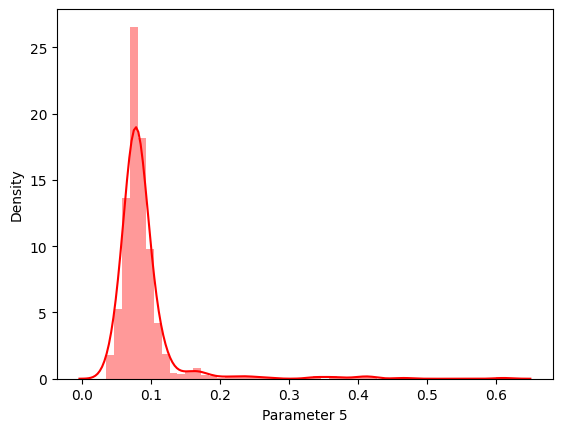

Distribution of  Parameter 5
Mean is: 0.0888972783143108
Median is: 0.079
Mode is: 0    0.078
1    0.080
Name: Parameter 5, dtype: float64
Standard deviation is: 0.05205890085074824
Skewness is: 5.310015644115136
Maximum is: 0.611
Minimum is: 0.034


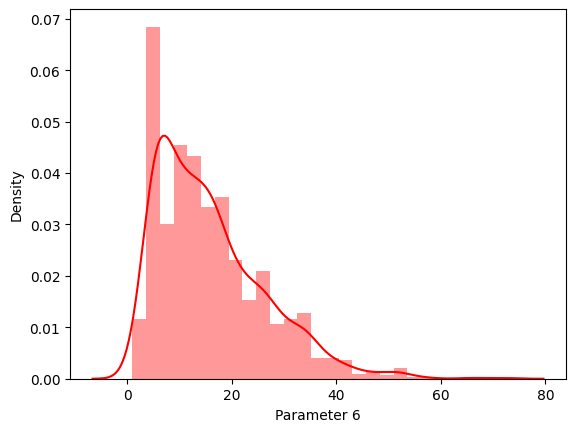

Distribution of  Parameter 6
Mean is: 15.929762949956102
Median is: 14.0
Mode is: 0    6.0
Name: Parameter 6, dtype: float64
Standard deviation is: 10.392574620239875
Skewness is: 1.1941467077254027
Maximum is: 72.0
Minimum is: 1.0


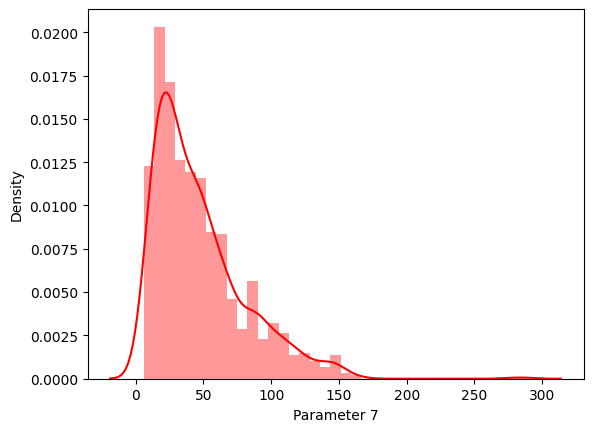

Distribution of  Parameter 7
Mean is: 47.15276558384548
Median is: 38.0
Mode is: 0    24.0
Name: Parameter 7, dtype: float64
Standard deviation is: 33.99345303952585
Skewness is: 1.5846303733443814
Maximum is: 289.0
Minimum is: 6.0


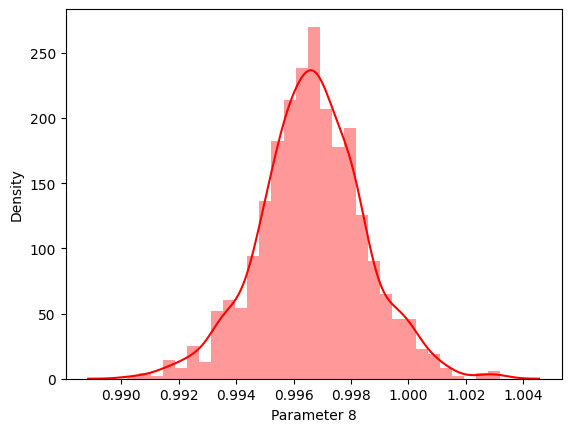

Distribution of  Parameter 8
Mean is: 0.9966482616330115
Median is: 0.99666
Mode is: 0    0.9968
Name: Parameter 8, dtype: float64
Standard deviation is: 0.0018345172569192174
Skewness is: 0.011417162600728187
Maximum is: 1.0032
Minimum is: 0.9902


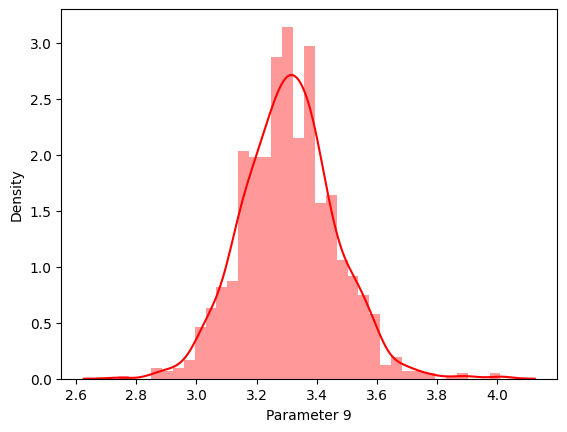

Distribution of  Parameter 9
Mean is: 3.308902546093064
Median is: 3.31
Mode is: 0    3.26
1    3.30
2    3.34
Name: Parameter 9, dtype: float64
Standard deviation is: 0.1551792664304459
Skewness is: 0.2736671598580435
Maximum is: 4.01
Minimum is: 2.74


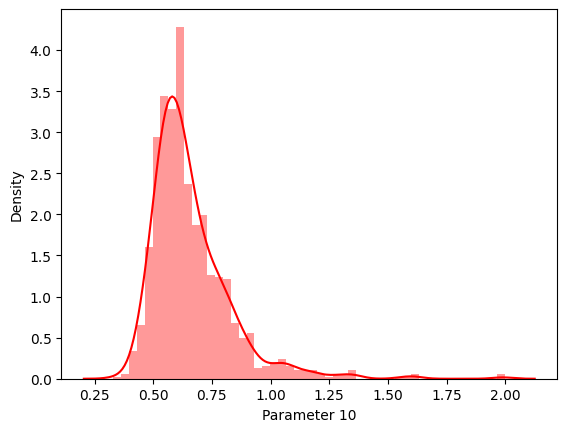

Distribution of  Parameter 10
Mean is: 0.6593064091308165
Median is: 0.62
Mode is: 0    0.54
Name: Parameter 10, dtype: float64
Standard deviation is: 0.17169769501605278
Skewness is: 2.3666624717187688
Maximum is: 2.0
Minimum is: 0.33


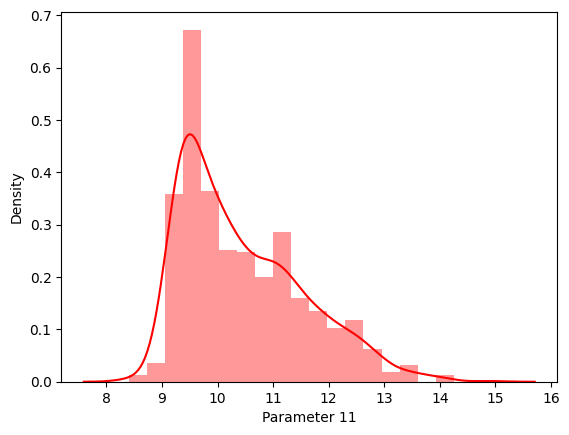

Distribution of  Parameter 11
Mean is: 10.441864208375767
Median is: 10.2
Mode is: 0    9.5
Name: Parameter 11, dtype: float64
Standard deviation is: 1.099889774314669
Skewness is: 0.8595552817400739
Maximum is: 14.9
Minimum is: 8.4


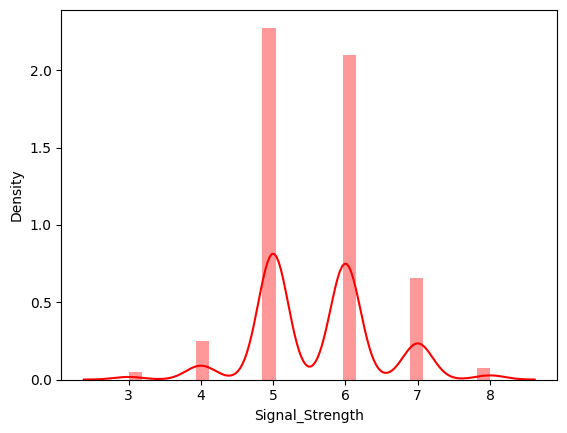

Distribution of  Signal_Strength
Mean is: 5.608428446005267
Median is: 6.0
Mode is: 0    5
Name: Signal_Strength, dtype: int64
Standard deviation is: 0.8433337722527776
Skewness is: 0.1631298923436497
Maximum is: 8
Minimum is: 3


In [60]:
# studying the distribution of continuous attributes
cols = list(df)
for i in np.arange(len(cols)):
    sns.distplot(df[cols[i]], color='red')
    #plt.xlabel('Experience')
    plt.show()
    print('Distribution of ',cols[i])
    print('Mean is:',df[cols[i]].mean())
    print('Median is:',df[cols[i]].median())
    print('Mode is:',df[cols[i]].mode())
    print('Standard deviation is:',df[cols[i]].std())
    print('Skewness is:',df[cols[i]].skew())
    print('Maximum is:',df[cols[i]].max())
    print('Minimum is:',df[cols[i]].min())

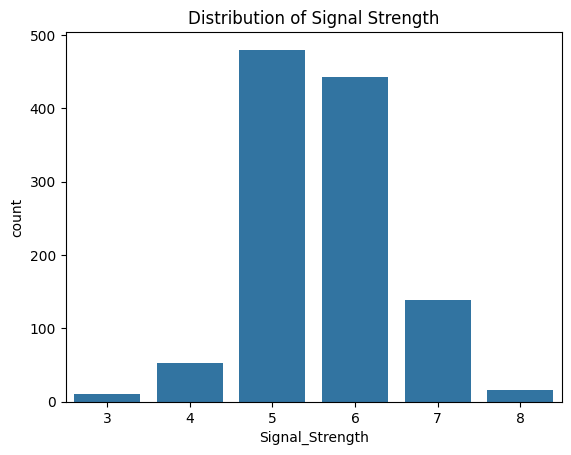

In [61]:
# Q1 D: Visualise distribution of the target variable.
sns.countplot(x='Signal_Strength', data=df)
plt.title('Distribution of Signal Strength')
plt.show()


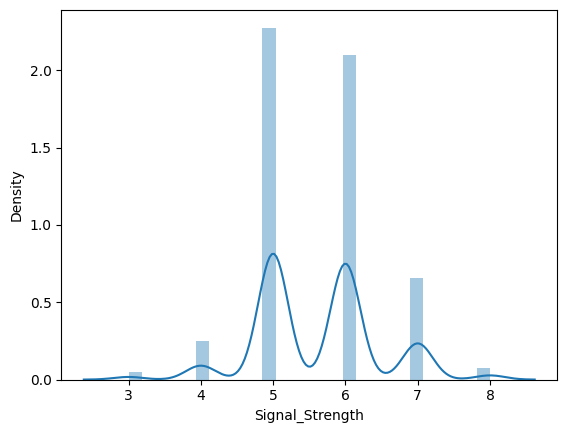

In [62]:
sns.distplot(df['Signal_Strength']);

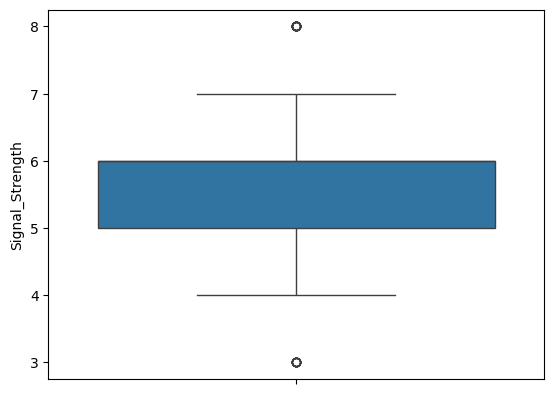

In [63]:
sns.boxplot(df['Signal_Strength']);

# Part A - Q1 E - Share insights from the initial data analysis (at least 2).

### Data Completeness and Quality:

Insight: The initial data analysis revealed that the dataset contained no missing values across all attributes. This is a positive indicator of data quality, as missing values can lead to biased model predictions and complicate the training process. Ensuring that the dataset is complete allows for more reliable model training and evaluation, as the model can learn from a full set of examples without gaps in the data.

### Class Imbalance in Target Variable:

Insight: The analysis of the target variable (Signal_Strength) indicated an imbalance in the distribution of classes. Some classes may have significantly more samples than others, which can lead to a model that is biased towards predicting the majority class. This imbalance can negatively impact the model's performance, particularly in its ability to accurately predict minority classes. Addressing class imbalance through techniques such as oversampling, undersampling, or using class weights during training is essential to improve the model's robustness and ensure fair predictions across all classes.

### Distribution of Continuous Attributes:

Insight: The distribution analysis of continuous attributes showed varying degrees of skewness and spread. For instance, some parameters exhibited a normal distribution, while others were skewed. Understanding the distribution of features is crucial for selecting appropriate preprocessing techniques, such as normalization or transformation, to ensure that the model can learn effectively. Features with high skewness may require transformation to improve their distribution and enhance model performance.

In [65]:
# Q2 A: Split the data into X & Y.
X = df.drop('Signal_Strength', axis=1)
Y = df['Signal_Strength']

In [66]:
# Q2 B: Split the data into train & test with 70:30 proportion.
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

In [67]:
# Q2 C: Print shape of all the 4 variables and verify if train and test data is in sync.
print(f"X_train shape: {X_train.shape}, Y_train shape: {Y_train.shape}")
print(f"X_test shape: {X_test.shape}, Y_test shape: {Y_test.shape}")

X_train shape: (797, 11), Y_train shape: (797,)
X_test shape: (342, 11), Y_test shape: (342,)


In [68]:
# Q2 D: Normalise the train and test data with appropriate method.
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [69]:
# Q2 E: Transform Labels into format acceptable by Neural Network
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
Y_train_encoded = label_encoder.fit_transform(Y_train)
Y_test_encoded = label_encoder.transform(Y_test)

In [70]:
# Q3 A: Design a Neural Network to train a classifier.
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(len(np.unique(Y_train_encoded)), activation='softmax')  # Assuming multi-class classification
])

In [71]:
# Q3 B: Train the classifier using previously designed Architecture
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model.fit(X_train_scaled, Y_train_encoded, validation_split=0.2, epochs=50, batch_size=32)


Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.2771 - loss: 1.6409 - val_accuracy: 0.5250 - val_loss: 1.3586
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5539 - loss: 1.2908 - val_accuracy: 0.5625 - val_loss: 1.1861
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5358 - loss: 1.1888 - val_accuracy: 0.5875 - val_loss: 1.1064
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5920 - loss: 1.0500 - val_accuracy: 0.6062 - val_loss: 1.0630
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5667 - loss: 1.0730 - val_accuracy: 0.5750 - val_loss: 1.0320
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5571 - loss: 1.0611 - val_accuracy: 0.6000 - val_loss: 1.0072
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5908 - loss: 1.0341 - val_accuracy: 0.6062 - val_loss: 0.9899
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6049 - loss: 0.9632 - val_accuracy: 0.5875 - val_loss

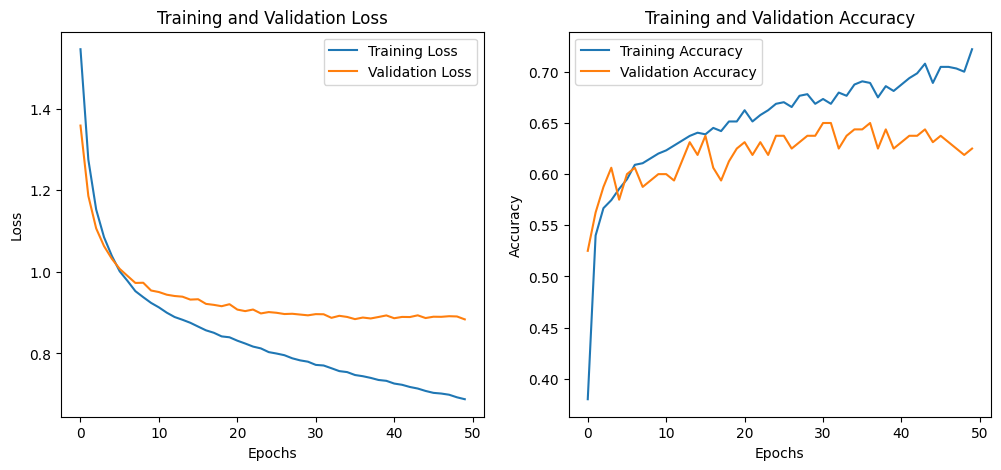

In [72]:
# Q3 C: Plot 2 separate visuals. i. Training Loss and Validation Loss ii. Training Accuracy and Validation Accuracy
plt.figure(figsize=(12, 5))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()


In [73]:
# Q3 D: Design new architecture/update existing architecture in attempt to improve the performance of the model.
model_improved = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    layers.Dropout(0.5),
    layers.Dense(64, activation='relu'),
    layers.Dense(len(np.unique(Y_train_encoded)), activation='softmax')
])


Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.3648 - loss: 1.5849 - val_accuracy: 0.5437 - val_loss: 1.2583
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5076 - loss: 1.2671 - val_accuracy: 0.5562 - val_loss: 1.0868
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5618 - loss: 1.1607 - val_accuracy: 0.6062 - val_loss: 1.0191
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5748 - loss: 1.0423 - val_accuracy: 0.6062 - val_loss: 0.9937
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5786 - loss: 1.0779 - val_accuracy: 0.6125 - val_loss: 0.9880
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6133 - loss: 1.0126 - val_accuracy: 0.6062 - val_loss: 0.9664
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5973 - loss: 0.9901 - val_accuracy: 0.5938 - val_loss: 0.9612
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6429 - loss: 0.9495 - val_accuracy: 0.6125 - val_loss

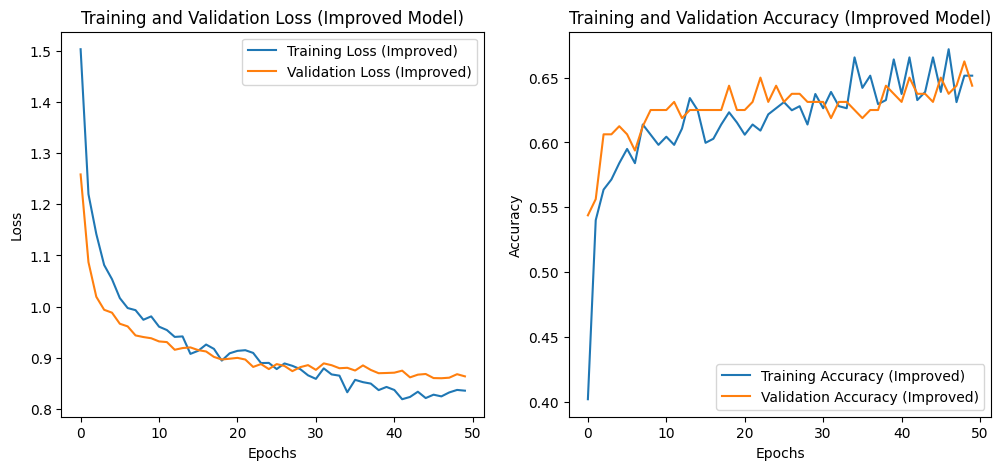

In [74]:
# Q3 E: Plot visuals as in Q3.C and share insights about difference observed in both the models.
model_improved.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history_improved = model_improved.fit(X_train_scaled, Y_train_encoded, validation_split=0.2, epochs=50, batch_size=32)

# Plotting for improved model
plt.figure(figsize=(12, 5))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(history_improved.history['loss'], label='Training Loss (Improved)')
plt.plot(history_improved.history['val_loss'], label='Validation Loss (Improved)')
plt.title('Training and Validation Loss (Improved Model)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(history_improved.history['accuracy'], label='Training Accuracy (Improved)')
plt.plot(history_improved.history['val_accuracy'], label='Validation Accuracy (Improved)')
plt.title('Training and Validation Accuracy (Improved Model)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()



### Training Loss:

* Initial Model: The training loss may decrease steadily, but if it does not converge well or shows fluctuations, it indicates that the model is struggling to learn effectively.

* Improved Model: The training loss should ideally decrease more smoothly and reach a lower value, indicating better learning and fitting to the training data.

### Validation Loss:

* Initial Model: If the validation loss starts to increase after a certain number of epochs while the training loss continues to decrease, this is a sign of overfitting.

* Improved Model: The validation loss should ideally decrease or stabilize, indicating that the model generalizes better to unseen data. A lower validation loss compared to the initial model suggests that the improvements made in architecture are effective.

### Training Accuracy:

* Initial Model: The training accuracy may increase but could plateau at a lower value, indicating that the model is not fully learning the patterns in the data.

* Improved Model: The training accuracy should ideally be higher and increase more consistently, reflecting better learning from the training dataset.

### Validation Accuracy:

* Initial Model: If the validation accuracy is significantly lower than the training accuracy, it indicates overfitting and poor generalization.

* Improved Model: The validation accuracy should be closer to the training accuracy, indicating that the model is performing well on both the training and validation datasets.

# **Part B: Digit Recognition using SVHN Dataset**

In [27]:
# Q1 A: Read the .h5 file and assign to a variable.
import h5py

In [28]:
# dataset path
h5f = h5py.File("/content/drive/MyDrive/svhn.h5",'r+')


## Part B - Q1 B - Print all the keys from the .h5 file.

In [29]:
#Names of the groups in Hdfs file
for key in h5f.keys():
    print(key)

X_test
X_train
X_val
y_test
y_train
y_val


## Part B - Q1 C - Split the data into X_train, X_test, Y_train, Y_test

In [30]:
# Load the training, test and validation set
X_train = h5f['X_train'][:]
y_train = h5f['y_train'][:]
X_test = h5f['X_test'][:]
y_test = h5f['y_test'][:]
X_val = h5f['X_val'][:]
y_val = h5f['y_val'][:]

## Part B - Q2 A - Print shape of all the 4 data split into x, y, train, test to verify if x & y is in sync.

In [48]:
X_train.shape

(42000, 10)

In [49]:
y_train.shape

(42000, 10)

In [31]:
X_train[:1]

array([[[ 33.0704,  30.2601,  26.852 , ...,  71.4471,  58.2204,
          42.9939],
        [ 25.2283,  25.5533,  29.9765, ..., 113.0209, 103.3639,
          84.2949],
        [ 26.2775,  22.6137,  40.4763, ..., 113.3028, 121.775 ,
         115.4228],
        ...,
        [ 28.5502,  36.212 ,  45.0801, ...,  24.1359,  25.0927,
          26.0603],
        [ 38.4352,  26.4733,  23.2717, ...,  28.1094,  29.4683,
          30.0661],
        [ 50.2984,  26.0773,  24.0389, ...,  49.6682,  50.853 ,
          53.0377]]], dtype=float32)

In [32]:
y_train[:1]

array([2], dtype=uint8)

In [33]:
X_test[:1]

array([[[ 40.558 ,  46.7917,  48.9764, ..., 112.1153, 112.9904,
         112.1646],
        [ 39.4379,  44.2911,  47.1768, ..., 111.0122, 110.9475,
         109.9368],
        [ 38.4488,  43.6394,  48.7098, ..., 109.8921, 109.9414,
         109.1048],
        ...,
        [ 34.9869,  35.4707,  39.6676, ..., 109.211 , 109.9074,
         112.7346],
        [ 35.6602,  35.5462,  40.3193, ..., 110.9998, 112.049 ,
         114.3431],
        [ 36.1871,  35.4214,  40.6998, ..., 110.0169, 111.2017,
         114.1906]]], dtype=float32)

In [34]:
y_test[:1]

array([1], dtype=uint8)

In [35]:
X_val[:1]

array([[[ 44.299 ,  45.9999,  51.3306, ...,  25.2764,  27.515 ,
          27.156 ],
        [ 49.1351,  60.3081,  70.1222, ...,  23.7002,  25.2378,
          24.2918],
        [ 60.7595,  83.7141, 102.1961, ...,  24.5044,  24.9712,
          22.8512],
        ...,
        [ 67.1072,  93.2464, 109.2017, ...,  26.6444,  24.6015,
          22.9607],
        [ 24.7569,  36.6417,  48.9071, ...,  21.9268,  21.5309,
          21.5479],
        [ 22.6584,  22.7724,  27.2666, ...,  21.443 ,  20.8191,
          20.0812]]], dtype=float32)

In [36]:
y_val[:1]

array([0], dtype=uint8)

## Part B - Q2 B - Visualise first 10 images in train data and print its corresponding labels.

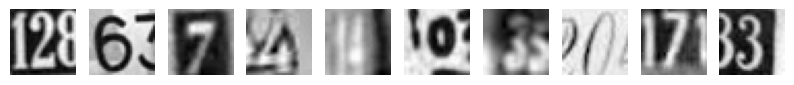

label for each of the above image: [2 6 7 4 4 0 3 0 7 3]


In [38]:
# visualizing the first 10 images in the dataset and their labels
%matplotlib inline
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 1))
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(X_train[i], cmap="gray")
    plt.axis('off')
plt.show()
print('label for each of the above image: %s' % (y_train[0:10]))

## Part B - Q2 C -Reshape all the images with appropriate shape update the data in same variable.

## Part B - Q2 D - Normalise the images i.e. Normalise the pixel values.


Need to reshape the X_train and X_test so that the same can be fed for model building. Currently we have a 3D tensor and we need to feed a 2D tensor into the model.

We will normalize the data. We divide by 255 as this is a grayscale image and can take values from 0-255

In [50]:
X_train = X_train.reshape(X_train.shape[0], 1024, 1)
X_test = X_test.reshape(X_test.shape[0], 1024, 1)

# # normalize inputs from 0-255 to 0-1
X_train = X_train / 255.0
X_test = X_test / 255.0

print('Resized Training set', X_train.shape, y_train.shape)
print('Resized Test set', X_test.shape, y_test.shape)

Resized Training set (42000, 1024, 1) (42000, 10)
Resized Test set (18000, 1024, 1) (18000, 10)


## Part B - Q2 E - Transform Labels into format acceptable by Neural Network

## Part B - Q2 F - Print total Number of classes in the Dataset.


To enhance model interpretability, we employ one-hot encoding for the target variables. This is necessary for our chosen loss function, categorical cross-entropy, which requires labels in one-hot encoded format

In [51]:
from tensorflow.keras.utils import to_categorical
# one hot encode outputs
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

# no.of classes
num_classes = y_test.shape[1]
print("The number of classes in this dataset are:",num_classes)

The number of classes in this dataset are: 10


## Part B - Q3 A - Design a Neural Network to train a classifier.

# Designing, training, tuning and testing a neural network image classifier.

#### Building the neural network model, fitting the training data, testing it and providing model summary.

In [52]:
# define model

from tensorflow.keras import optimizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

def nn_model():
    # create model
    model = Sequential()
    model.add(Flatten())
    model.add(Dense(256, activation='relu')) ###Multiple Dense units with Relu activation
    model.add(Dense(64, activation='relu'))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(num_classes, activation='softmax'))
    return model

creating an object of our model

## Part B - Q3 B - Train the classifier using previously designed Architecture (Use best suitable parameters).

In [53]:
# build the model
model = nn_model()

In [45]:
# Compile model
sgd = optimizers.Adam(learning_rate=1e-3)

### Loss function = Categorical cross entropy
model.compile(loss='categorical_crossentropy', optimizer=sgd, metrics=['accuracy'])

Fitting the model on the training dataset along with it's equivalent one hot encoded labels

In [46]:
# Fitting the model
training_history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=100, batch_size=300, verbose=2)

Epoch 1/100
140/140 - 4s - 31ms/step - accuracy: 0.1096 - loss: 2.2999 - val_accuracy: 0.1332 - val_loss: 2.2777
Epoch 2/100
140/140 - 2s - 16ms/step - accuracy: 0.1983 - loss: 2.1400 - val_accuracy: 0.3418 - val_loss: 1.8492
Epoch 3/100
140/140 - 3s - 24ms/step - accuracy: 0.4452 - loss: 1.6296 - val_accuracy: 0.5292 - val_loss: 1.4272
Epoch 4/100
140/140 - 4s - 30ms/step - accuracy: 0.5433 - loss: 1.4008 - val_accuracy: 0.5868 - val_loss: 1.2897
Epoch 5/100
140/140 - 2s - 14ms/step - accuracy: 0.5927 - loss: 1.2719 - val_accuracy: 0.6008 - val_loss: 1.2410
Epoch 6/100
140/140 - 2s - 14ms/step - accuracy: 0.6208 - loss: 1.1995 - val_accuracy: 0.6382 - val_loss: 1.1448
Epoch 7/100
140/140 - 3s - 18ms/step - accuracy: 0.6322 - loss: 1.1608 - val_accuracy: 0.6545 - val_loss: 1.1041
Epoch 8/100
140/140 - 4s - 26ms/step - accuracy: 0.6530 - loss: 1.1107 - val_accuracy: 0.6536 - val_loss: 1.1065
Epoch 9/100
140/140 - 3s - 22ms/step - accuracy: 0.6635 - loss: 1.0706 - val_accuracy: 0.6669 - 

## Part B - Q3 C - Evaluate performance of the model with appropriate metrics.

Plotting the training loss, validation loss vs number of epochs and training accuracy,

In [47]:
# Final evaluation of the model
scores = model.evaluate(X_test, y_test, verbose=0)
print("Loss:", scores[0])
print("Accuracy:", scores[1])

Loss: 0.677920401096344
Accuracy: 0.8101111054420471


Text(0.5, 1.0, 'Training and validation loss')

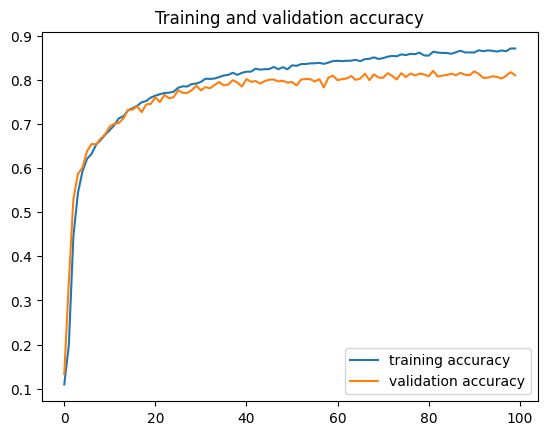

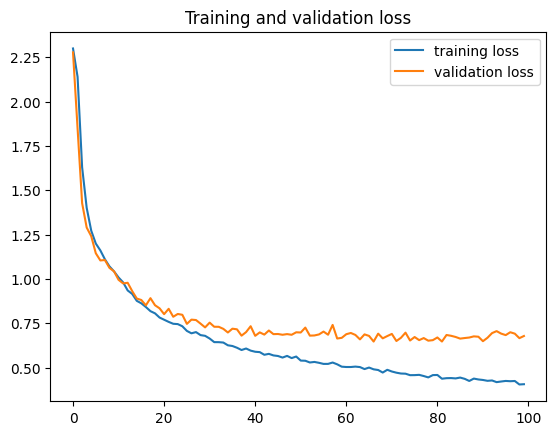

In [75]:
accuracy      = training_history.history['accuracy']
val_accuracy  = training_history.history['val_accuracy']
loss     = training_history.history['loss']
val_loss = training_history.history['val_loss']

epochs   = range(len(accuracy)) # Get number of epochs

plt.plot  ( epochs, accuracy, label = 'training accuracy' )
plt.plot  ( epochs, val_accuracy, label = 'validation accuracy' )
plt.title ('Training and validation accuracy')
plt.legend(loc = 'lower right')
plt.figure()

plt.plot  ( epochs, loss, label = 'training loss' )
plt.plot  ( epochs, val_loss, label = 'validation loss' )
plt.legend(loc = 'upper right')
plt.title ('Training and validation loss'   )

* The dataset comprises approximately 10 distinct classes, each corresponding to a digit between 0 and 9.

* We observe that the model exhibits overfitting behavior after a certain training stage. This is evident in the plots, where the validation loss starts to rise and the validation accuracy begins to decline








* We experimented with Neural Networks featuring dense hidden layers with varying numbers of units. The highest test accuracy achieved was 80.86%.